# Lab 8: Heuristic Search Algorithms

## Setup

In [36]:
import heapq
from collections import deque

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

%matplotlib inline

plt.rcParams["figure.figsize"] = (10, 7)
plt.rcParams["figure.dpi"] = 100

## Part 1: Building a Weighted Graph with Heuristic Values

### 1.2 Building the Graph

In [37]:
# Build the Ireland map as a weighted graph
ireland = nx.Graph()

# Add edges with distances (km)
edges = [
    ("Galway", "Limerick", 130),
    ("Galway", "Belfast", 306),
    ("Limerick", "Cork", 100),
    ("Limerick", "Dublin", 196),
    ("Cork", "Waterford", 122),
    ("Cork", "Dublin", 259),
    ("Dublin", "Belfast", 167),
    ("Dublin", "Waterford", 167),
]

for city_a, city_b, distance in edges:
    ireland.add_edge(city_a, city_b, weight=distance)

# Heuristic: straight-line distance to Waterford (km)
heuristic = {
    "Galway": 200,
    "Limerick": 170,
    "Belfast": 270,
    "Cork": 120,
    "Dublin": 130,
    "Waterford": 0,
}

# Store heuristic as node attribute
for city, h in heuristic.items():
    ireland.nodes[city]["h"] = h

print("Cities:", sorted(ireland.nodes()))
print("\nConnections and distances:")
for u, v, data in sorted(ireland.edges(data=True)):
    print(f" {u} <-> {v}: {data['weight']} km")

print("\nHeuristic values (crow-flies distance to Waterford):")
for city, h in sorted(heuristic.items(), key=lambda x: x[1]):
    print(f" {city}: h = {h} km")

Cities: ['Belfast', 'Cork', 'Dublin', 'Galway', 'Limerick', 'Waterford']

Connections and distances:
 Belfast <-> Dublin: 167 km
 Cork <-> Dublin: 259 km
 Cork <-> Waterford: 122 km
 Dublin <-> Waterford: 167 km
 Galway <-> Belfast: 306 km
 Galway <-> Limerick: 130 km
 Limerick <-> Cork: 100 km
 Limerick <-> Dublin: 196 km

Heuristic values (crow-flies distance to Waterford):
 Waterford: h = 0 km
 Cork: h = 120 km
 Dublin: h = 130 km
 Limerick: h = 170 km
 Galway: h = 200 km
 Belfast: h = 270 km


### 1.3 Visualising the Ireland Map
We draw the weighted graph and display heuristic values h(n) beside each city.

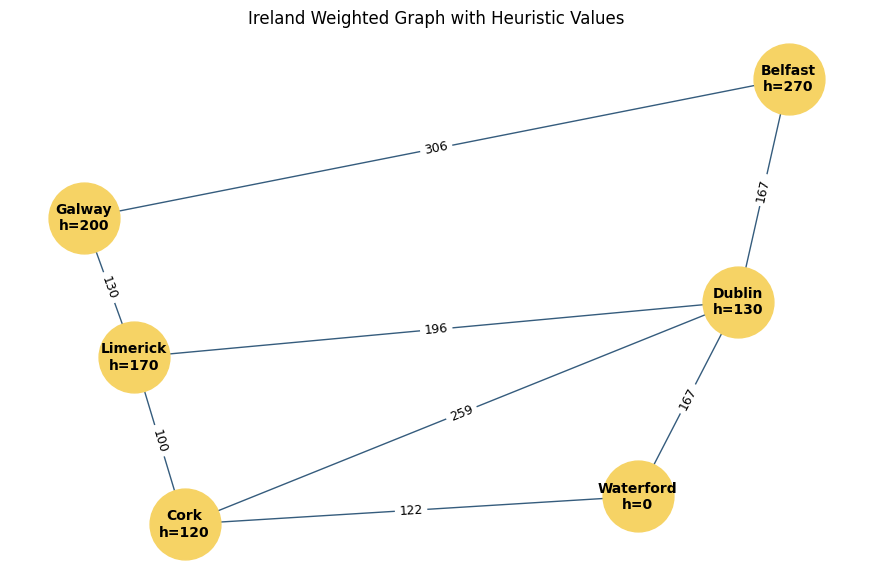

In [38]:
# Approximate geographic layout for readability
pos = {
    "Galway": (-1.0, 0.2),
    "Limerick": (-0.9, -0.3),
    "Cork": (-0.8, -0.9),
    "Dublin": (0.3, -0.1),
    "Waterford": (0.1, -0.8),
    "Belfast": (0.4, 0.7),
}

edge_labels = {(u, v): d["weight"] for u, v, d in ireland.edges(data=True)}
node_labels = {city: f"{city}\nh={heuristic[city]}" for city in ireland.nodes()}

plt.figure(figsize=(11, 7))
nx.draw_networkx(
    ireland,
    pos=pos,
    labels=node_labels,
    node_color="#f6d365",
    edge_color="#355c7d",
    node_size=2600,
    font_size=10,
    font_weight="bold",
)
nx.draw_networkx_edge_labels(ireland, pos=pos, edge_labels=edge_labels, font_size=9)
plt.title("Ireland Weighted Graph with Heuristic Values")
plt.axis("off")
plt.show()

### 1.4 Admissibility and Consistency
For goal `Waterford`, we test whether the heuristic is admissible (`h(n) <= true_cost(n, goal)`) and consistent (`h(n) <= c(n,n') + h(n')` for each edge).

In [39]:
goal = "Waterford"

# True shortest-path costs to the goal from every city
true_cost_to_goal = nx.single_source_dijkstra_path_length(ireland, goal, weight="weight")

admissibility_violations = []
for city, h_value in heuristic.items():
    if h_value > true_cost_to_goal[city]:
        admissibility_violations.append((city, h_value, true_cost_to_goal[city]))

consistency_violations = []
for u, v, data in ireland.edges(data=True):
    w = data["weight"]
    if heuristic[u] > w + heuristic[v]:
        consistency_violations.append((u, v, heuristic[u], w + heuristic[v]))
    if heuristic[v] > w + heuristic[u]:
        consistency_violations.append((v, u, heuristic[v], w + heuristic[u]))

print("True costs to Waterford:")
for city in sorted(true_cost_to_goal):
    print(f" {city}: {true_cost_to_goal[city]} km")

print("\nAdmissibility:", "PASS" if not admissibility_violations else "FAIL")
if admissibility_violations:
    for city, h_value, true_cost in admissibility_violations:
        print(f"  Violation at {city}: h={h_value} > true_cost={true_cost}")

print("\nConsistency:", "PASS" if not consistency_violations else "FAIL")
if consistency_violations:
    for src, dst, h_src, bound in consistency_violations:
        print(f"  Violation: h({src})={h_src} > c({src},{dst})+h({dst})={bound}")

True costs to Waterford:
 Belfast: 334 km
 Cork: 122 km
 Dublin: 167 km
 Galway: 352 km
 Limerick: 222 km
 Waterford: 0 km

Admissibility: PASS

Consistency: PASS


## Part 2: Hill Climbing (Steepest Ascent)
### 2.1 How Hill Climbing Works
At each step, move to the neighboring city with the lowest heuristic value. If no neighbor has a lower heuristic, the algorithm gets stuck (local optimum or plateau).

### 2.2 Hill Climbing Implementation

In [40]:
def path_cost(graph, path):
    if len(path) < 2:
        return 0
    return sum(graph[path[i]][path[i + 1]]["weight"] for i in range(len(path) - 1))


def hill_climbing(graph, start, goal, h):
    current = start
    path = [current]
    visited = {current}
    trace = [f"Start at {current} (h={h[current]})"]

    while current != goal:
        neighbors = sorted(graph.neighbors(current), key=lambda n: (h[n], n))
        candidates = [n for n in neighbors if n not in visited]

        if not candidates:
            trace.append("No unvisited neighbors left -> stuck.")
            return path, None, False, trace

        best = candidates[0]
        trace.append(
            f"At {current}: choose {best} (h={h[best]}) from {[(n, h[n]) for n in candidates]}"
        )

        if h[best] >= h[current]:
            trace.append(
                f"No improvement (next h={h[best]} >= current h={h[current]}) -> local optimum/plateau."
            )
            return path, None, False, trace

        current = best
        path.append(current)
        visited.add(current)

    return path, path_cost(graph, path), True, trace

### 2.3 Hill Climbing on the Base Map

In [41]:
hc_path, hc_cost, hc_ok, hc_trace = hill_climbing(
    ireland, start="Galway", goal="Waterford", h=heuristic
    )

print("Hill Climbing Trace:")
for step in hc_trace:
    print(" -", step)

print("\nResult:")
print(" Path:", " -> ".join(hc_path))
print(" Goal reached:", hc_ok)
print(" Cost:", hc_cost if hc_ok else "N/A")

Hill Climbing Trace:
 - Start at Galway (h=200)
 - At Galway: choose Limerick (h=170) from [('Limerick', 170), ('Belfast', 270)]
 - At Limerick: choose Cork (h=120) from [('Cork', 120), ('Dublin', 130)]
 - At Cork: choose Waterford (h=0) from [('Waterford', 0), ('Dublin', 130)]

Result:
 Path: Galway -> Limerick -> Cork -> Waterford
 Goal reached: True
 Cost: 352


### 2.4 Foothills: Adding Athlone
We add a foothill node (`Athlone`) with a deceptively low heuristic that can trap hill climbing.

In [42]:
ireland_foothill = ireland.copy()
ireland_foothill.add_edge("Galway", "Athlone", weight=80)
ireland_foothill.add_edge("Athlone", "Dublin", weight=75)

heuristic_foothill = dict(heuristic)
heuristic_foothill["Athlone"] = 90

foothill_path, foothill_cost, foothill_ok, foothill_trace = hill_climbing(
    ireland_foothill, start="Galway", goal="Waterford", h=heuristic_foothill
    )

print("Hill Climbing with Athlone Foothill:")
for step in foothill_trace:
    print(" -", step)

print("\nResult:")
print(" Path:", " -> ".join(foothill_path))
print(" Goal reached:", foothill_ok)
print(" Cost:", foothill_cost if foothill_ok else "N/A")

Hill Climbing with Athlone Foothill:
 - Start at Galway (h=200)
 - At Galway: choose Athlone (h=90) from [('Athlone', 90), ('Limerick', 170), ('Belfast', 270)]
 - At Athlone: choose Dublin (h=130) from [('Dublin', 130)]
 - No improvement (next h=130 >= current h=90) -> local optimum/plateau.

Result:
 Path: Galway -> Athlone
 Goal reached: False
 Cost: N/A


### 2.5 Plateaux: Adding Nenagh and Adjusting Athlone
Now we create a plateau by giving equal heuristic values to neighboring options.

In [43]:
ireland_plateau = ireland_foothill.copy()
ireland_plateau.add_edge("Limerick", "Nenagh", weight=35)
ireland_plateau.add_edge("Nenagh", "Athlone", weight=95)

heuristic_plateau = dict(heuristic_foothill)
heuristic_plateau["Athlone"] = 170
heuristic_plateau["Nenagh"] = 170

plateau_path, plateau_cost, plateau_ok, plateau_trace = hill_climbing(
    ireland_plateau, start="Galway", goal="Waterford", h=heuristic_plateau
    )

print("Hill Climbing with Plateau:")
for step in plateau_trace:
    print(" -", step)

print("\nResult:")
print(" Path:", " -> ".join(plateau_path))
print(" Goal reached:", plateau_ok)
print(" Cost:", plateau_cost if plateau_ok else "N/A")

Hill Climbing with Plateau:
 - Start at Galway (h=200)
 - At Galway: choose Athlone (h=170) from [('Athlone', 170), ('Limerick', 170), ('Belfast', 270)]
 - At Athlone: choose Dublin (h=130) from [('Dublin', 130), ('Nenagh', 170)]
 - At Dublin: choose Waterford (h=0) from [('Waterford', 0), ('Cork', 120), ('Limerick', 170), ('Belfast', 270)]

Result:
 Path: Galway -> Athlone -> Dublin -> Waterford
 Goal reached: True
 Cost: 322


## Part 3: Greedy Best-First Search
### 3.1 How Greedy Best-First Search Works
Greedy best-first uses a priority queue sorted only by heuristic `h(n)`. It is complete on finite graphs with cycle detection, but not optimal.

### 3.2 Greedy Best-First Implementation

In [44]:
def greedy_best_first_search(graph, start, goal, h):
    frontier = [(h[start], start, [start])]
    visited = set()
    trace = []

    while frontier:
        h_value, node, path = heapq.heappop(frontier)
        if node in visited:
            continue

        visited.add(node)
        trace.append(f"Pop {node} with h={h_value}; frontier_size={len(frontier)}")

        if node == goal:
            return path, path_cost(graph, path), True, trace

        for nbr in sorted(graph.neighbors(node)):
            if nbr not in visited:
                heapq.heappush(frontier, (h[nbr], nbr, path + [nbr]))
                trace.append(f"  push {nbr} with h={h[nbr]}")

    return [], None, False, trace


gbfs_path, gbfs_cost, gbfs_ok, gbfs_trace = greedy_best_first_search(
    ireland, start="Galway", goal="Waterford", h=heuristic
    )

print("Greedy Best-First Search Trace:")
for step in gbfs_trace:
    print(" -", step)

print("\nResult:")
print(" Path:", " -> ".join(gbfs_path) if gbfs_path else "None")
print(" Goal reached:", gbfs_ok)
print(" Cost:", gbfs_cost if gbfs_ok else "N/A")

Greedy Best-First Search Trace:
 - Pop Galway with h=200; frontier_size=0
 -   push Belfast with h=270
 -   push Limerick with h=170
 - Pop Limerick with h=170; frontier_size=1
 -   push Cork with h=120
 -   push Dublin with h=130
 - Pop Cork with h=120; frontier_size=2
 -   push Dublin with h=130
 -   push Waterford with h=0
 - Pop Waterford with h=0; frontier_size=3

Result:
 Path: Galway -> Limerick -> Cork -> Waterford
 Goal reached: True
 Cost: 352


## Part 4: Beam Search
### 4.1 How Beam Search Works
Beam search expands level by level but keeps only the best `k` partial paths at each depth (by heuristic of path end-node). It can miss solutions if good paths are pruned early.
### 4.2 Beam Search Implementation

In [45]:
def beam_search(graph, start, goal, h, beam_width=2, max_depth=20):
    beam = [[start]]
    trace = [f"Initial beam: {beam}"]

    for depth in range(max_depth):
        expanded = []
        for path in beam:
            node = path[-1]
            if node == goal:
                return path, path_cost(graph, path), True, trace
            for nbr in sorted(graph.neighbors(node)):
                if nbr not in path:
                    expanded.append(path + [nbr])

        if not expanded:
            return [], None, False, trace + ["No expansions left."]

        expanded.sort(key=lambda p: (h[p[-1]], len(p), p[-1]))
        beam = expanded[:beam_width]
        trace.append(f"Depth {depth + 1}: {beam}")

        for path in beam:
            if path[-1] == goal:
                return path, path_cost(graph, path), True, trace

    return [], None, False, trace + ["Max depth reached."]


beam_path, beam_cost, beam_ok, beam_trace = beam_search(
    ireland, start="Galway", goal="Waterford", h=heuristic, beam_width=2
    )

print("Beam Search Trace (k=2):")
for step in beam_trace:
    print(" -", step)

print("\nResult:")
print(" Path:", " -> ".join(beam_path) if beam_path else "None")
print(" Goal reached:", beam_ok)
print(" Cost:", beam_cost if beam_ok else "N/A")

Beam Search Trace (k=2):
 - Initial beam: [['Galway']]
 - Depth 1: [['Galway', 'Limerick'], ['Galway', 'Belfast']]
 - Depth 2: [['Galway', 'Limerick', 'Cork'], ['Galway', 'Limerick', 'Dublin']]
 - Depth 3: [['Galway', 'Limerick', 'Cork', 'Waterford'], ['Galway', 'Limerick', 'Dublin', 'Waterford']]

Result:
 Path: Galway -> Limerick -> Cork -> Waterford
 Goal reached: True
 Cost: 352


## Part 5: A* Search
### 5.1 How A* Works
A* uses evaluation function `f(n) = g(n) + h(n)`, where `g(n)` is path cost from start and `h(n)` estimates remaining cost to goal.
### 5.2 A* Implementation

In [46]:
def astar_search(graph, start, goal, h):
    open_heap = [(h[start], 0, start, [start])]
    best_g = {start: 0}
    closed = []
    trace = []

    while open_heap:
        f, g, node, path = heapq.heappop(open_heap)

        if g > best_g.get(node, float("inf")):
            continue

        closed.append(node)
        trace.append(f"Expand {node}: g={g}, h={h[node]}, f={f}")

        if node == goal:
            return path, g, True, trace

        for nbr in sorted(graph.neighbors(node)):
            edge_cost = graph[node][nbr]["weight"]
            g_new = g + edge_cost
            if g_new < best_g.get(nbr, float("inf")):
                best_g[nbr] = g_new
                f_new = g_new + h[nbr]
                heapq.heappush(open_heap, (f_new, g_new, nbr, path + [nbr]))
                trace.append(
                    f"  push {nbr}: g={g_new}, h={h[nbr]}, f={f_new}"
                )

    return [], None, False, trace


print("A* Search Trace:")
a_path, a_cost, a_ok, a_trace = astar_search(
    ireland, start="Galway", goal="Waterford", h=heuristic
    )
for step in a_trace:
    print(" -", step)

print("\nResult:")
print(" Path:", " -> ".join(a_path) if a_path else "None")
print(" Goal reached:", a_ok)
print(" Cost:", a_cost if a_ok else "N/A")

A* Search Trace:
 - Expand Galway: g=0, h=200, f=200
 -   push Belfast: g=306, h=270, f=576
 -   push Limerick: g=130, h=170, f=300
 - Expand Limerick: g=130, h=170, f=300
 -   push Cork: g=230, h=120, f=350
 -   push Dublin: g=326, h=130, f=456
 - Expand Cork: g=230, h=120, f=350
 -   push Waterford: g=352, h=0, f=352
 - Expand Waterford: g=352, h=0, f=352

Result:
 Path: Galway -> Limerick -> Cork -> Waterford
 Goal reached: True
 Cost: 352


### 5.3 A* on the Ireland Map

In [47]:
print("A* path:", " -> ".join(a_path))
print("A* total cost:", a_cost, "km")

A* path: Galway -> Limerick -> Cork -> Waterford
A* total cost: 352 km


### 5.4 A* with the Athlone Foothill

In [48]:
a2_path, a2_cost, a2_ok, _ = astar_search(
    ireland_foothill, start="Galway", goal="Waterford", h=heuristic_foothill
    )
print("A* with Athlone foothill:")
print(" Path:", " -> ".join(a2_path) if a2_path else "None")
print(" Goal reached:", a2_ok)
print(" Cost:", a2_cost if a2_ok else "N/A")

A* with Athlone foothill:
 Path: Galway -> Athlone -> Dublin -> Waterford
 Goal reached: True
 Cost: 322


### 5.5 Verifying with NetworkX

In [49]:
nx_path = nx.astar_path(
    ireland,
    source="Galway",
    target="Waterford",
    heuristic=lambda n, _: heuristic[n],
    weight="weight",
)
nx_cost = path_cost(ireland, nx_path)

print("NetworkX A* path:", " -> ".join(nx_path))
print("NetworkX A* cost:", nx_cost, "km")
print("Matches custom A*:", nx_path == a_path and nx_cost == a_cost)

NetworkX A* path: Galway -> Limerick -> Cork -> Waterford
NetworkX A* cost: 352 km
Matches custom A*: True


## Part 6: Algorithm Comparison

In [50]:
results = [
    {
        "Algorithm": "Hill Climbing (base)",
        "Path": " -> ".join(hc_path),
        "Cost": hc_cost if hc_ok else "N/A",
        "Reached Goal": hc_ok,
        "Optimal": hc_cost == a_cost if hc_ok else False,
    },
    {
        "Algorithm": "Greedy Best-First",
        "Path": " -> ".join(gbfs_path) if gbfs_ok else "None",
        "Cost": gbfs_cost if gbfs_ok else "N/A",
        "Reached Goal": gbfs_ok,
        "Optimal": gbfs_cost == a_cost if gbfs_ok else False,
    },
    {
        "Algorithm": "Beam Search (k=2)",
        "Path": " -> ".join(beam_path) if beam_ok else "None",
        "Cost": beam_cost if beam_ok else "N/A",
        "Reached Goal": beam_ok,
        "Optimal": beam_cost == a_cost if beam_ok else False,
    },
    {
        "Algorithm": "A*",
        "Path": " -> ".join(a_path) if a_ok else "None",
        "Cost": a_cost if a_ok else "N/A",
        "Reached Goal": a_ok,
        "Optimal": True if a_ok else False,
    },
]

print("Algorithm Comparison:\n")
for row in results:
    print(
        f"- {row['Algorithm']}: path={row['Path']}, cost={row['Cost']}, "
        f"reached_goal={row['Reached Goal']}, optimal={row['Optimal']}"
    )

Algorithm Comparison:

- Hill Climbing (base): path=Galway -> Limerick -> Cork -> Waterford, cost=352, reached_goal=True, optimal=True
- Greedy Best-First: path=Galway -> Limerick -> Cork -> Waterford, cost=352, reached_goal=True, optimal=True
- Beam Search (k=2): path=Galway -> Limerick -> Cork -> Waterford, cost=352, reached_goal=True, optimal=True
- A*: path=Galway -> Limerick -> Cork -> Waterford, cost=352, reached_goal=True, optimal=True


## Part 7: A* with Different Evaluation Functions
### 7.1 Grid World with Terrain
We use a grid where each cell has terrain cost: `1` easy, `3` rough, `9` blocked.
### 7.2 Building the Grid World

In [51]:
grid = np.array(
    [
        [1, 3, 3, 3, 3, 3, 3, 1],
        [1, 1, 1, 1, 1, 1, 1, 1],
        [1, 9, 9, 9, 1, 9, 9, 1],
        [1, 1, 1, 9, 1, 1, 1, 1],
        [1, 9, 1, 9, 1, 9, 1, 1],
        [1, 9, 1, 1, 1, 9, 1, 1],
        [1, 1, 1, 9, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1],
    ]
    )

start_cell = (0, 0)
goal_cell = (7, 7)
blocked_value = 9

print("Grid shape:", grid.shape)
print("Start:", start_cell, "Goal:", goal_cell)

Grid shape: (8, 8)
Start: (0, 0) Goal: (7, 7)


### 7.3 A* with Different Cost Functions

In [52]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def grid_neighbors(cell, grid_array, blocked=9):
    r, c = cell
    rows, cols = grid_array.shape
    candidates = [(r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)]
    valid = []
    for nr, nc in candidates:
        if 0 <= nr < rows and 0 <= nc < cols and grid_array[nr, nc] != blocked:
            valid.append((nr, nc))
    return valid


def astar_grid(grid_array, start, goal, step_cost_fn):
    open_heap = [(manhattan(start, goal), 0, start, [start])]
    best_g = {start: 0}

    while open_heap:
        f, g, cell, path = heapq.heappop(open_heap)
        if g > best_g.get(cell, float("inf")):
            continue
        if cell == goal:
            return path, g

        for nbr in grid_neighbors(cell, grid_array, blocked=blocked_value):
            move_cost = step_cost_fn(grid_array, nbr)
            g_new = g + move_cost
            if g_new < best_g.get(nbr, float("inf")):
                best_g[nbr] = g_new
                f_new = g_new + manhattan(nbr, goal)
                heapq.heappush(open_heap, (f_new, g_new, nbr, path + [nbr]))

    return [], None


distance_only_cost = lambda g, cell: 1
terrain_aware_cost = lambda g, cell: int(g[cell])

path_distance, cost_distance = astar_grid(
    grid, start_cell, goal_cell, step_cost_fn=distance_only_cost
    )
path_terrain, cost_terrain = astar_grid(
    grid, start_cell, goal_cell, step_cost_fn=terrain_aware_cost
    )

print("Distance-only A* cost:", cost_distance, "steps")
print("Terrain-aware A* cost:", cost_terrain, "terrain units")
print("Distance-only path length:", len(path_distance))
print("Terrain-aware path length:", len(path_terrain))

Distance-only A* cost: 14 steps
Terrain-aware A* cost: 14 terrain units
Distance-only path length: 15
Terrain-aware path length: 15


### 7.4 Visualising Both Paths

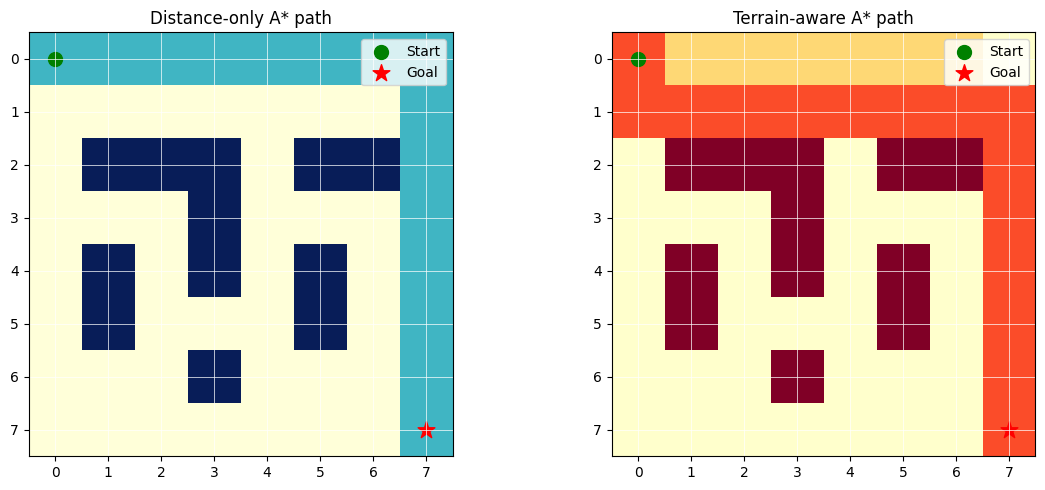

In [53]:
def overlay_path(mask, path, value):
    for r, c in path:
        mask[r, c] = value
    return mask

distance_overlay = grid.astype(float).copy()
terrain_overlay = grid.astype(float).copy()
overlay_path(distance_overlay, path_distance, 5)
overlay_path(terrain_overlay, path_terrain, 6)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(distance_overlay, cmap="YlGnBu")
axes[0].set_title("Distance-only A* path")
axes[1].imshow(terrain_overlay, cmap="YlOrRd")
axes[1].set_title("Terrain-aware A* path")

for ax in axes:
    ax.scatter(start_cell[1], start_cell[0], marker="o", s=100, c="green", label="Start")
    ax.scatter(goal_cell[1], goal_cell[0], marker="*", s=160, c="red", label="Goal")
    ax.set_xticks(range(grid.shape[1]))
    ax.set_yticks(range(grid.shape[0]))
    ax.grid(True, color="white", linewidth=0.5)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

### 7.5 The Evaluation Function Determines the Solution
Different cost functions can produce different optimal paths even with the same heuristic.

In [54]:
def summarize_grid_path(path, grid_array):
    if not path:
        return {"steps": None, "terrain_cost": None}
    steps = len(path) - 1
    terrain_cost = int(sum(grid_array[cell] for cell in path[1:]))
    return {"steps": steps, "terrain_cost": terrain_cost}

summary_distance = summarize_grid_path(path_distance, grid)
summary_terrain = summarize_grid_path(path_terrain, grid)

print("Grid A* comparison:")
print(
    f" - Distance-only: steps={summary_distance['steps']}, "
    f"terrain_cost={summary_distance['terrain_cost']}"
    )
print(
    f" - Terrain-aware: steps={summary_terrain['steps']}, "
    f"terrain_cost={summary_terrain['terrain_cost']}"
    )

Grid A* comparison:
 - Distance-only: steps=14, terrain_cost=26
 - Terrain-aware: steps=14, terrain_cost=14
